# Marketing Analytics of Corporate Travel Data: A Deep Dive into Client Behavior and Sales Channels

### **Introduction**

**Project Goal (The "Why"):**
The primary goal of this project is to perform an end-to-end analysis of corporate travel data, simulating the role of a Marketing Analyst. The key objective is to move beyond simple descriptive metrics to uncover actionable insights into client behavior and sales channel effectiveness, culminating in a set of strategic business recommendations.

**Dataset (The "What"):**
The analysis is based on a relational dataset consisting of three interconnected tables:
*   `users`: Contains demographic and corporate information about the travelers.
*   `flights`: Includes detailed records of flight bookings.
*   `hotels`: Contains records of hotel bookings.

**Tools and Methodology (The "How"):**
This analysis is conducted within a Jupyter Notebook. The primary tools used are:
*   **SQL** (via `ipython-sql`) for complex data querying, aggregation, and transformation directly from the SQLite database.
*   **Python Libraries** (`Pandas` for data manipulation, `Matplotlib` for data visualization) for further analysis and presentation of findings.
The project structure follows a logical progression, starting with a high-level financial overview and progressively drilling down into specific aspects of client and partner behavior.

In [2]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

<hr>
<h2 align="center">UML Diagram of Database</h2>
<img src="images/travel_data.gif">

<hr>
<h2 align="center">Connecting to local database</h2>

In [3]:
%load_ext sql


In [4]:
%sql sqlite:///travel_data.db
%config SqlMagic.style = '_DEPRECATED_DEFAULT'

<hr>
<h2 align="center">Client Financial Profile Analysis</h2>

In [5]:
%%sql company_expenses_df <<
WITH flight_prices AS 
    (SELECT 
        travelCode,
        userCode,
        SUM(price) AS tickets_price
    FROM flights
    GROUP BY travelCode, userCode),
total_prices AS
    (SELECT 
        f.*, 
        u.company, 
        COALESCE(total,0) AS hotel_price,
        tickets_price + COALESCE(total,0) AS total_bill 
    FROM flight_prices AS f
    LEFT JOIN hotels AS h
        ON f.travelCode = h.travelCode
    JOIN users AS u
        ON f.userCode = u.Code
    )
SELECT 
    company,
    ROUND(SUM(tickets_price)) AS tickets_spends,
    ROUND(SUM(hotel_price)) AS hotel_spends,
    ROUND(SUM(total_bill)) AS total_bill,
    COUNT(*) AS travels_count,
    ROUND(AVG(total_bill)) AS average_bill,
    ROUND(AVG(tickets_price)) AS average_ticket_spends,
    ROUND(AVG(hotel_price)) AS average_hotel_spends
FROM total_prices
GROUP BY company
ORDER BY total_bill DESC



 * sqlite:///travel_data.db
Done.
Returning data to local variable company_expenses_df


In [6]:
company_expenses_df = company_expenses_df.DataFrame()
company_expenses_df.head()

,company,tickets_spends,hotel_spends,total_bill,travels_count,average_bill,average_ticket_spends,average_hotel_spends
0,4You,86243818.0,7486217.0,93730035.0,46493,2016.0,1855.0,161.0
1,Acme Factory,53636603.0,3903736.0,57540339.0,25472,2259.0,2106.0,153.0
2,Umbrella LTDA,43926402.0,3200189.0,47126591.0,20798,2266.0,2112.0,154.0
3,Wonka Company,40505639.0,3665447.0,44171085.0,22941,1925.0,1766.0,160.0
4,Monsters CYA,35986321.0,3489591.0,39475912.0,20240,1950.0,1778.0,172.0


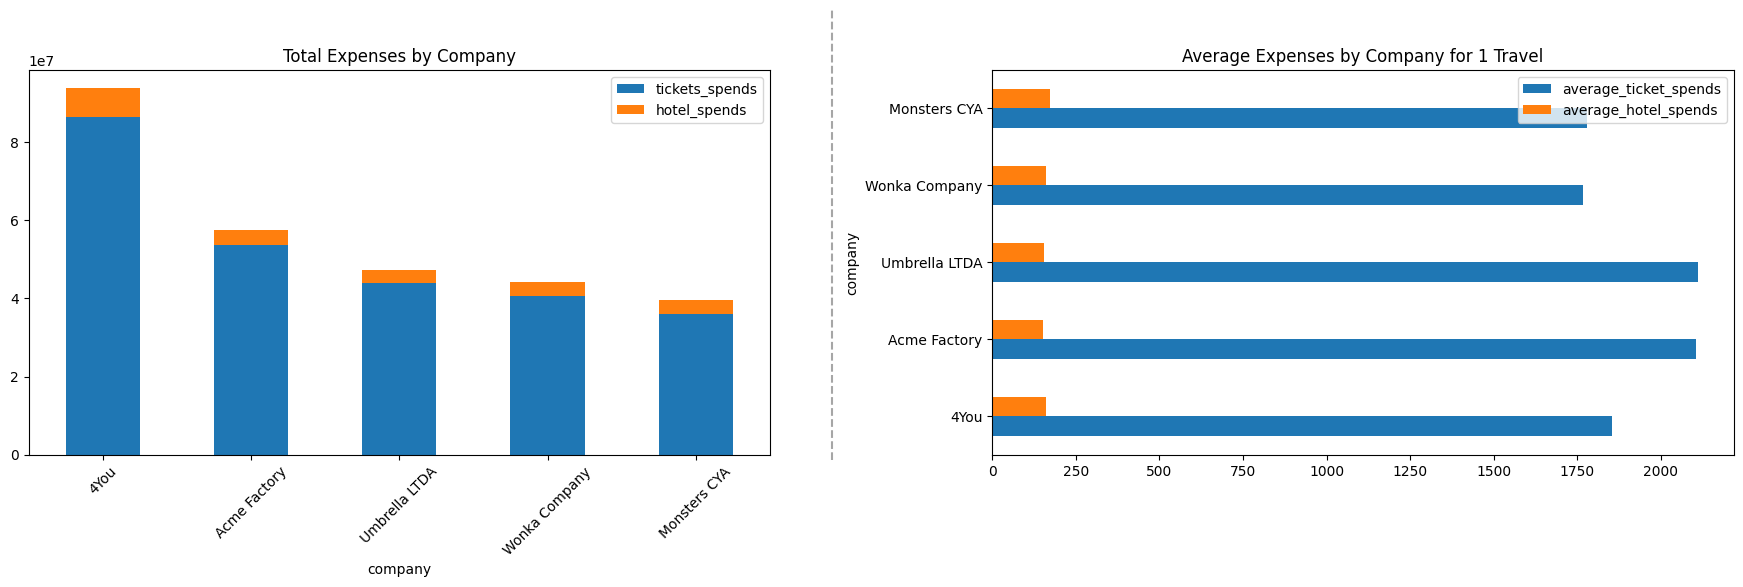

In [7]:
import matplotlib.lines as lines

company_expenses_df_sorted = company_expenses_df.sort_values(
    by="total_bill", ascending=False
)


fig, axes = plt.subplots(nrows=1, ncols=2, gridspec_kw={"wspace": 0.3}, figsize=(22, 5))
line = lines.Line2D(
    [0.49, 0.49],
    [0.1, 1],  # X and Y coords for vertical line
    transform=fig.transFigure,
    color="gray",
    linestyle="--",
    linewidth=1.5,
    alpha=0.7,
)

# Adding line
fig.add_artist(line)

# PLOT #1
plt1 = company_expenses_df_sorted.plot(
    kind="bar",
    x="company",
    y=["tickets_spends", "hotel_spends"],
    title="Total Expenses by Company",
    stacked=True,
    rot=45,
    ax=axes[0],
)


# PLOT #2
plt2 = company_expenses_df_sorted.plot(
    kind="barh",
    x="company",
    y=["average_ticket_spends", "average_hotel_spends"],
    title="Average Expenses by Company for 1 Travel",
    ax=axes[1],
)


<h4>
<u>Observation 1</u>: "4You" is our largest client, with spending that doubles the next competitor, driven purely by a higher volume of trips.</br>
<u>Insight 1</u>: This creates a significant concentration risk. Our primary goal must be <b>long-term retention</b>.</br>
<u>Recommendation 1</u>:
<ul>
    <li>Action: Prioritize signing an <b>exclusive multi-year contract</b>.</li>
    <li>Goal: Secure revenue and build a strong competitive barrier.</li>
</ul>

<u>Observation 2</u>: All other clients exhibit similar spending patterns per trip, but with lower frequency</br>
<u>Insight 2</u>: This segment offers a major opportunity for growth and <b>diversification</b>, reducing our dependency on a single client.</br>
<u>Recommendation 2</u>:
<ul>
    <li>Action: <b>Launch targeted "Growth Incentive Programs"</b> (e.g., volume-based discounts)</b>.</li>
    <li>Goal:  Increase our "share of wallet" and grow these accounts into major partners.</li>
</ul>
</h4>


<hr>
<h2 align="center">Analysis of Key Travel Corridors</h2>

In [8]:
%%sql
WITH company_routes AS
(SELECT 
    company,
    "from",
    "to",
    COUNT(*) AS travels_count
FROM flights f
JOIN users u
    ON f.userCode = u.code
GROUP BY company, "from", "to"
),
ranked_routes AS 
(
SELECT 
    company,
    "from",
    "to",
    travels_count,
    RANK() OVER (PARTITION BY company ORDER BY travels_count DESC) AS rank
FROM company_routes
)
SELECT * FROM ranked_routes
WHERE rank = 1

 * sqlite:///travel_data.db
Done.


company,from,to,travels_count,rank
4You,Aracaju (SE),Recife (PE),3962,1
4You,Recife (PE),Aracaju (SE),3962,1
Acme Factory,Campo Grande (MS),Florianopolis (SC),3276,1
Acme Factory,Florianopolis (SC),Campo Grande (MS),3276,1
Monsters CYA,Campo Grande (MS),Sao Paulo (SP),2640,1
Monsters CYA,Sao Paulo (SP),Campo Grande (MS),2640,1
Umbrella LTDA,Aracaju (SE),Florianopolis (SC),2661,1
Umbrella LTDA,Florianopolis (SC),Aracaju (SE),2661,1
Wonka Company,Aracaju (SE),Natal (RN),1974,1
Wonka Company,Natal (RN),Aracaju (SE),1974,1



<u>Observation</u>: The analysis revealed that each of our key clients has a dominant business travel corridor — a pair of cities with a high and consistent volume of trips in both directions. The key corridors are:
<ul>
<li><b>4You: Aracaju (SE) ↔ Recife (PE)</b></li>
<li><b>Monsters CYA: Campo Grande (MS) ↔ Sao Paulo (SP)</b></li>
<li><b>Acme Factory: Campo Grande (MS) ↔ Florianopolis (SC)</b></li>
<li><b>Umbrella LTDA: Aracaju (SE) ↔ Florianopolis (SC)</b></li>
<li><b>Wonka Company: Aracaju (SE) ↔ Natal (RN)</b></li>
</ul>

<br>
<u>Insight</u>: This pattern indicates that these routes are tied to our clients' critical and recurring business operations (e.g., connecting a head office with a major branch). This high predictability and volume give us significant leverage and an opportunity to create a high-margin, value-added service instead of just selling individual tickets.
<br>
<u>Recommendation</u>: Based on this insight, I recommend moving from a transactional sales model to a proactive, solution-oriented approach for these specific corridors:
<ul>
<li>
<strong>1. Develop a "Business Corridor Package":</strong><br>
Create a bundled service for each client focused on their key route. This package should include flexible flight tickets, negotiated corporate rates with partner hotels in <u>both</u> cities, and value-added services like airport transfers.
<ul>
<li><strong>Goal:</strong> Increase our profit margin and build strong client loyalty by offering a superior, tailored solution.</li>
</ul>
</li>
<br>
<li>
<strong>2. Proactive Sales Outreach:</strong><br>
Equip the sales team with this data to approach each client with a personalized proposal, demonstrating our deep understanding of their business needs.
<ul>
<li><strong>Goal:</strong> Transition from being a simple vendor to becoming an indispensable travel management partner.</li>
</ul>
</li>
</ul>
</h4>

<hr>
<h2 align="center"> Client Travel Style & Preference Analysis</h2>

In [9]:
%%sql flights_info_by_company <<
SELECT
    company,
    ROUND(AVG(distance)) AS average_distance,
    SUM(CASE WHEN flightType = "economic" THEN 1 ELSE 0 END) AS economic_flights,
    SUM(CASE WHEN flightType = "firstClass" THEN 1 ELSE 0 END) AS first_class_flights,
    SUM(CASE WHEN flightType = "premium" THEN 1 ELSE 0 END) AS premium_flights
FROM flights f
LEFT JOIN users u
    ON f.userCode = u.Code
GROUP BY company
ORDER BY average_distance DESC

 * sqlite:///travel_data.db
Done.
Returning data to local variable flights_info_by_company


In [10]:
flights_info_by_company = flights_info_by_company.DataFrame()
flights_info_by_company

,company,average_distance,economic_flights,first_class_flights,premium_flights
0,Umbrella LTDA,672.0,11766,17888,11942
1,Acme Factory,672.0,14616,21570,14758
2,4You,503.0,26282,40170,26534
3,Monsters CYA,469.0,11512,17320,11648
4,Wonka Company,453.0,13290,19470,13122


<Axes: title={'center': 'Average distance of flight by company'}, ylabel='company'>

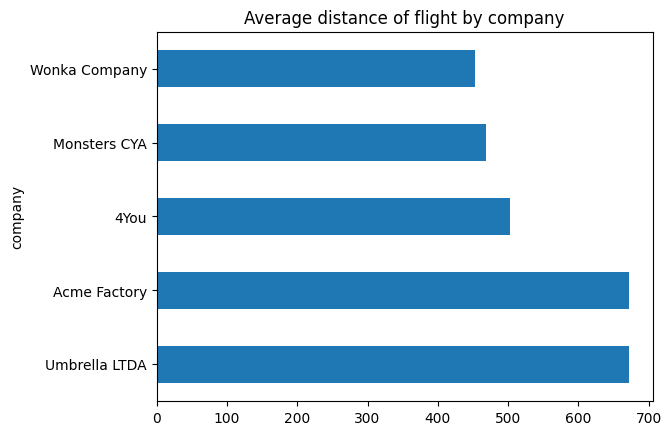

In [11]:
flights_info_by_company.plot(
    kind="barh",
    x="company",
    y="average_distance",
    title="Average distance of flight by company",
    legend=False,
)

<Axes: title={'center': 'The proportion of flights in different classes in each company'}, xlabel='company'>

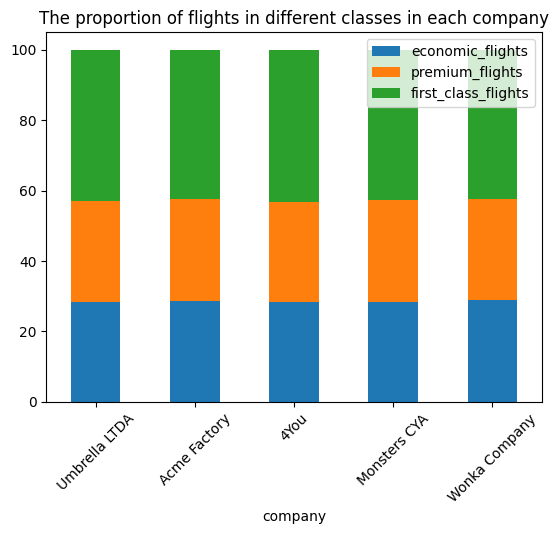

In [12]:
flight_class_info = flights_info_by_company[
    ["company", "economic_flights", "premium_flights", "first_class_flights"]
].set_index("company")
flight_class_info = flight_class_info.div(flight_class_info.sum(axis=1), axis=0) * 100

flight_class_info.plot(
    kind="bar",
    stacked=True,
    title="The proportion of flights in different classes in each company",
    rot=45,
)

<h4>
<u><strong>Observation 1</strong></u>: Some companies have a significantly longer average flight distance.<br>
<u><strong>Insight</strong></u>: Most likely, these companies either have a wider geographical reach or a greater international business impact.<br> 
<u><strong>Recommendation</strong></u>: Find solutions to increase the comfort and productivity of passengers (e.g., fast track for economy class, access to business lounges, more prestigious hotel transfers, etc.) who fly farther and longer, and offer them a corresponding package of such services, which will increase our company's revenue through margins on these services.<br>

<u><strong>Observation 2</strong></u>: First class flights are the most popular among our customers<br>
<u><strong>Insight</strong></u>:Our company primarily serves premium corporate clients for whom comfort and status are a priority. Consequently, we should position ourselves as a premium service provider, using lower-tier classes (Economy, Premium) strategically as customer acquisition or loyalty tools, rather than core products.<br>
<u><strong>Recommendation</strong></u>: Create loyalty programs for regular customers and conduct a marketing campaign among potential new customers, based on receiving additional economy/premium class flights for the company after booking a certain number of first class flights<br>
</h4>



<hr>
<h2 align="center">Demographic Profile Analysis</h2>

In [13]:
%%sql demographic_info <<
SELECT 
    company,
    COUNT(*) as users_count,
    ROUND(AVG(age),1) as average_age,
    SUM(CASE WHEN gender LIKE "female" THEN 1 ELSE 0 END) AS female_count,
    SUM(CASE WHEN gender LIKE "male" THEN 1 ELSE 0 END) AS male_count,
    SUM(CASE WHEN gender LIKE "none" THEN 1 ELSE 0 END) AS nodata_count
FROM users
GROUP BY company
ORDER BY users_count DESC

 * sqlite:///travel_data.db
Done.
Returning data to local variable demographic_info


In [14]:
demographic_info = demographic_info.DataFrame()
demographic_info.head()

,company,users_count,average_age,female_count,male_count,nodata_count
0,4You,453,42.7,151,138,164
1,Acme Factory,261,42.1,85,93,83
2,Wonka Company,237,43.1,79,90,68
3,Monsters CYA,195,43.8,64,61,70
4,Umbrella LTDA,194,42.2,69,70,55


<Axes: title={'center': 'The proportion of genders of users in each company'}, xlabel='company'>

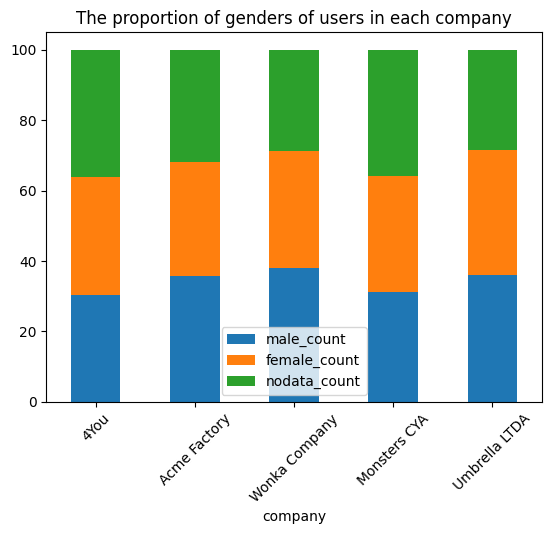

In [15]:
demographic_info = demographic_info[
    ["company", "male_count", "female_count", "nodata_count"]
].set_index("company")
demographic_info_plot = demographic_info.div(demographic_info.sum(axis=1), axis=0) * 100

demographic_info_plot.plot(
    kind="bar",
    stacked=True,
    title="The proportion of genders of users in each company",
    rot=45,
)


<h4>
<u>Observation </u>: The average age of users in each company is similar, at around 42-43 years old.The gender distribution is also at similar levels. It should be noted that more than 30 percent of users did not provide gender data, marking this information as confidential.</br>
<u>Insight </u>: This indicates that our client base is homogenous from a demographic perspective. It implies that <b>factors like a person's company and its travel policies are much stronger predictors of their travel behavior (like choice of class or destination) than their age or gender.</b></br>
<u>Recommendation</u>:
 Marketing and sales efforts should be segmented based on company profiles and their specific travel patterns (e.g., the "business corridors" we identified), rather than on demographic characteristics. <b>Targeting users based on age or gender is unlikely to be an effective strategy for this client segment.</b>





<hr>
<h2 align="center">Travel Agency Effectiveness Analysis</h2>

In [16]:
%%sql
SELECT 
    agency,
    ROUND(SUM(price)) AS total_price,
    ROUND(AVG(price),2) AS avg_price,
    COUNT(*) AS num_of_flights
FROM flights 
GROUP BY agency

 * sqlite:///travel_data.db
Done.


agency,total_price,avg_price,num_of_flights
CloudFy,106939335.0,918.9,116378
FlyingDrops,45973204.0,1186.16,38758
Rainbow,107386243.0,919.78,116752


In [17]:
%%sql 
SELECT
    agency,
    SUM(CASE WHEN flightType = "economic" THEN 1 ELSE 0 END) AS economic_flights,
    SUM(CASE WHEN flightType = "firstClass" THEN 1 ELSE 0 END) AS first_class_flights,
    SUM(CASE WHEN flightType = "premium" THEN 1 ELSE 0 END) AS premium_flights
FROM flights f
GROUP BY agency


 * sqlite:///travel_data.db
Done.


agency,economic_flights,first_class_flights,premium_flights
CloudFy,38656,38862,38860
FlyingDrops,0,38758,0
Rainbow,38810,38798,39144



<h4>
<u>Observation</u>: CloudFly and Rainbow performed a similar number of flights with almost identical average costs, while <b>FlyingDrops performed significantly fewer flights, but the average cost of each flight was ~30% higher</b> because they <b>exclusively sell First Class tickets</b>.</br>
<u>Insight</u>: <b>The FlyingDrops agency organizes premium flights only, and partnering with them gives us access to a high-margin market segment</b>. Increasing sales through this channel will allow us to increase our company's overall profits.</br>
<u>Recommendation</u>:
<b>Conduct a joint marketing campaign with FlyingDrops targeting the premium segment</b>, using suggestions from the analysis blocks above and the agency's own customer base and <b>offer FlyingDrops exclusive partnership terms</b>.

<li>
   <b>Goal:</b> Solidify our market leadership in the premium segment and maximize profitability by investing in our most valuable sales channel.
</li>





In [18]:
%%sql company_x_agency <<
SELECT 
    company,
    agency,
    COUNT(*) AS num_of_flights
FROM flights f 
LEFT JOIN users u
    ON f.userCode = u.Code
GROUP BY company, agency

 * sqlite:///travel_data.db
Done.
Returning data to local variable company_x_agency


In [19]:
# Showing as pivot for better understading
company_x_agency_pivot = pd.pivot_table(
    data=company_x_agency.DataFrame(),
    values="num_of_flights",
    index="company",
    columns="agency",
)
company_x_agency_pivot

agency,CloudFy,FlyingDrops,Rainbow
company,,,
4You,39692.0,13434.0,39860.0
Acme Factory,22044.0,7176.0,21724.0
Monsters CYA,17312.0,5722.0,17446.0
Umbrella LTDA,17708.0,5938.0,17950.0
Wonka Company,19622.0,6488.0,19772.0


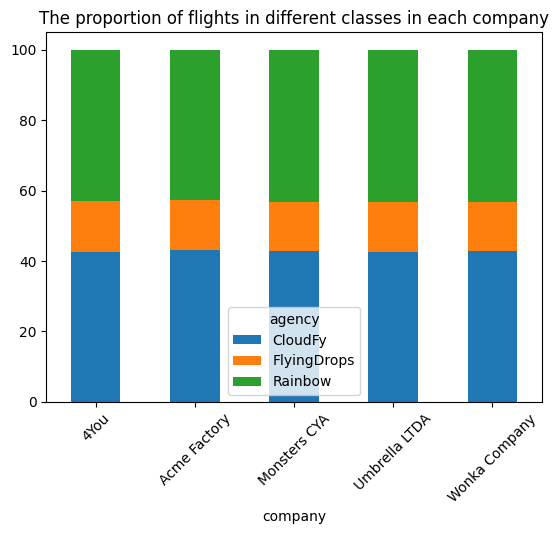

In [21]:

# company_x_agency_pivot = company_x_agency_pivot[["company","economic_flights","premium_flights","first_class_flights"]].set_index("company")
company_x_agency_plot = (
    company_x_agency_pivot.div(company_x_agency_pivot.sum(axis=1), axis=0) * 100
)

company_x_agency_plot.plot(
    kind="bar",
    stacked=True,
    title="The proportion of flights in different classes in each company",
    rot=45,
)
plt.show()


<h4>
<u>Observation</u>: <b>Each of the five companies demonstrates a virtually identical agency selection strategy</b>: approximately 40-45% of bookings are made through CloudFy, 10-15% through FlyingDrops, and the remaining ~45% through Rainbow.</br>
<u>Insight</u>: We already know that FlyingDrops is our exclusive channel for selling our highest-margin product—First Class. The fact that this channel accounts for only 10-15% of bookings, even among our premium customers, is a <b>huge missed opportunity</b>. We are not using our best tool to increase profitability.</br>
<u>Recommendation</u>:
<ul>
<li>
<b>1. Introduce a "First Class" Incentive for Key Clients:</b><br>
Launch a targeted campaign for our top clients ("4You", "Acme Factory"), offering them a special bonus (e.g., a free airport transfer, bonus loyalty points) for every `First Class` flight booked specifically through <b>FlyingDrops</b>.
</li>
<li>
<b>2. Align Sales & Partnership Goals:</b><br>
Set a clear KPI for our sales and partnership teams: <b>"Increase the share of bookings via 'FlyingDrops' from 15% to 25% within the next six months."</b> This goal should be supported by the exclusive partnership terms we offer them.
</li>
</ul>
<u>Goal</u>: Consciously reshape our sales mix to increase overall profitability, rather than just chasing volume.





<hr><hr><hr>

# Final Summary & Key Recommendations

This analysis of corporate travel data revealed two critical insights that should shape our future business strategy: 

**1. Our business is heavily reliant on a single, high-volume client ("4You"), creating a significant concentration risk.** At the same time, our client base consists of **premium-oriented companies** that prioritize `First Class` travel, which is our core, high-margin product.

**2. Our sales channels are not optimized.** We have a specialized, high-value premium channel ("FlyingDrops") that is **critically underutilized**, while the majority of sales go through high-volume, lower-margin agencies.

Based on these findings, the following strategic recommendations are proposed:

### **Strategic Recommendations:**

#### **Strategy 1: Solidify and Diversify the Client Base**
*   **Action (Retention):** Immediately engage our key client, "4You," with an offer for an **exclusive long-term contract** to secure this crucial revenue stream.
*   **Action (Growth):** Implement targeted **"Growth Incentive Programs"** for other clients to increase their booking volume, thereby diversifying our revenue and reducing dependency on a single account.

#### **Strategy 2: Optimize Sales Channels for Profitability**
*   **Action (Partnership):** Develop a **strategic partnership with "FlyingDrops"**, offering them exclusive terms to motivate the sales of our most profitable products (`First Class` travel).
*   **Action (Marketing):** Launch a **joint marketing campaign** with our premium partners to consciously shift the sales mix towards higher-margin channels and products.

By implementing these strategies, we can not only mitigate current risks but also unlock significant potential for increased profitability and market leadership in the premium corporate travel segment.